In [18]:
import json
import pandas as pd
import torchvision.transforms as t
from PIL import Image
import torch
import wfdb
import matplotlib.pyplot as plt

In [31]:
def get_cxr(cxr_pt, split):
    img = Image.open(cxr_pt).convert('RGB')

    # square crop
    if split == "train":
        crop = t.RandomCrop((320, 320))
    else:
        crop = t.CenterCrop((320, 320))

    transform = t.Compose([
        # smaller edge is scaled to `cxr_scale`. i.e, if height > width,
        # then img is rescaled to (cxr_scale * height / width, cxr_scale)
        t.Resize(320),
        crop,
        t.ToTensor()
    ])

    cxr = transform(img)
    cxr = (cxr * 255)
    assert torch.all(cxr == cxr.long()), "cxr tensor is not integer-valued."
    return cxr.to(torch.uint8)


def get_ecg(ecg_pt):
    signal = torch.from_numpy(wfdb.rdrecord(ecg_pt).p_signal)

    # normalize to be between -1 and 1
    signal = 2 * (signal - signal.min()) / (signal.max() - signal.min()) - 1

    return signal.unsqueeze(0).to(torch.float32)

In [26]:
val_df = pd.read_csv("/gpfs/scratch/as16583/symile/symile/risk_prediction/datasets/val.csv")

cxr_pt = "/gpfs/data/ranganathlab/mimic-cxr-jpg/mimic-cxr-jpg-2.0.0.physionet.org/"
ecg_pt = "/gpfs/data/ranganathlab/mimic-iv-ecg/1.0/"

cxr_pt = cxr_pt + val_df.iloc[0]["cxr_path"]
ecg_pt = ecg_pt + val_df.iloc[0]["ecg_path"]

mean_cxr = torch.load("/gpfs/scratch/as16583/symile/symile/risk_prediction/datasets/mean_cxr.pt")
mean_ecg = torch.load("/gpfs/scratch/as16583/symile/symile/risk_prediction/datasets/mean_ecg.pt")

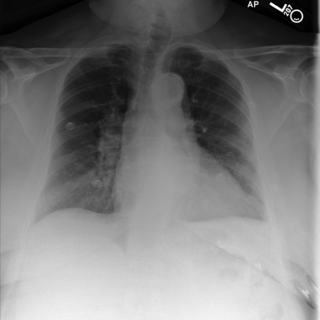

In [11]:
cxr = get_cxr(cxr_pt, "val").float() / 255
t.ToPILImage()(cxr)

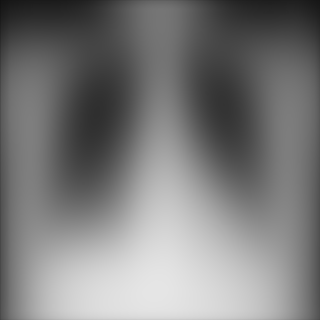

In [15]:
t.ToPILImage()(mean_cxr)

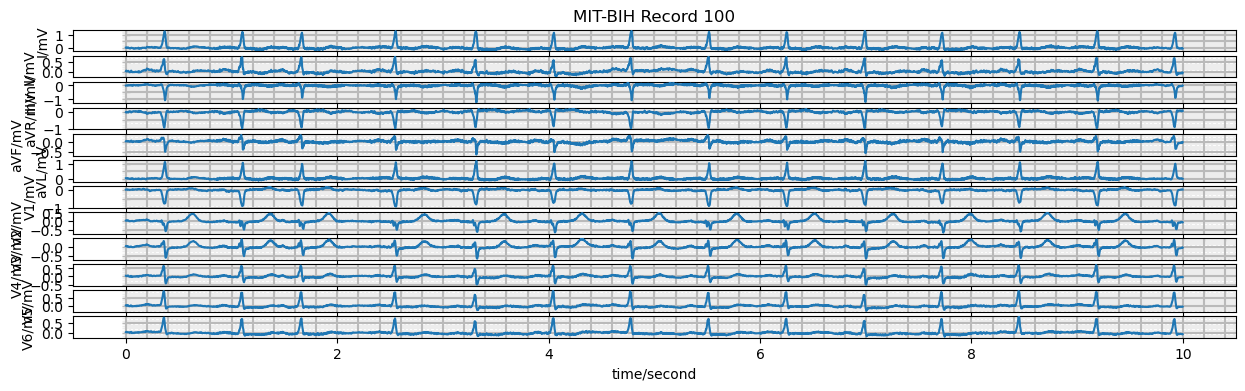

In [24]:
record = wfdb.rdrecord(ecg_pt)
wfdb.plot_wfdb(record=record, plot_sym=True,
                   time_units='seconds', title='MIT-BIH Record 100',
                   figsize=(15,4), ecg_grids='all')

tensor([[[-6.3494e-04,  9.4573e-04, -1.3691e-03,  ...,  2.4329e-03,
           4.1771e-04, -1.7831e-03],
         [-1.7441e-03,  8.9430e-05, -1.1120e-03,  ...,  1.2696e-03,
          -6.5091e-04, -2.5323e-03],
         [-2.3812e-03, -5.7971e-04, -1.1654e-03,  ...,  5.8543e-04,
          -1.1897e-03, -2.8630e-03],
         ...,
         [ 1.0952e-02,  6.3344e-03, -7.5697e-03,  ...,  7.8219e-03,
           1.0597e-02,  1.0263e-02],
         [ 1.0880e-02,  6.1594e-03, -7.6742e-03,  ...,  7.7283e-03,
           1.0617e-02,  1.0371e-02],
         [ 1.1038e-02,  6.0666e-03, -7.8940e-03,  ...,  7.9877e-03,
           1.1004e-02,  1.0701e-02]]])

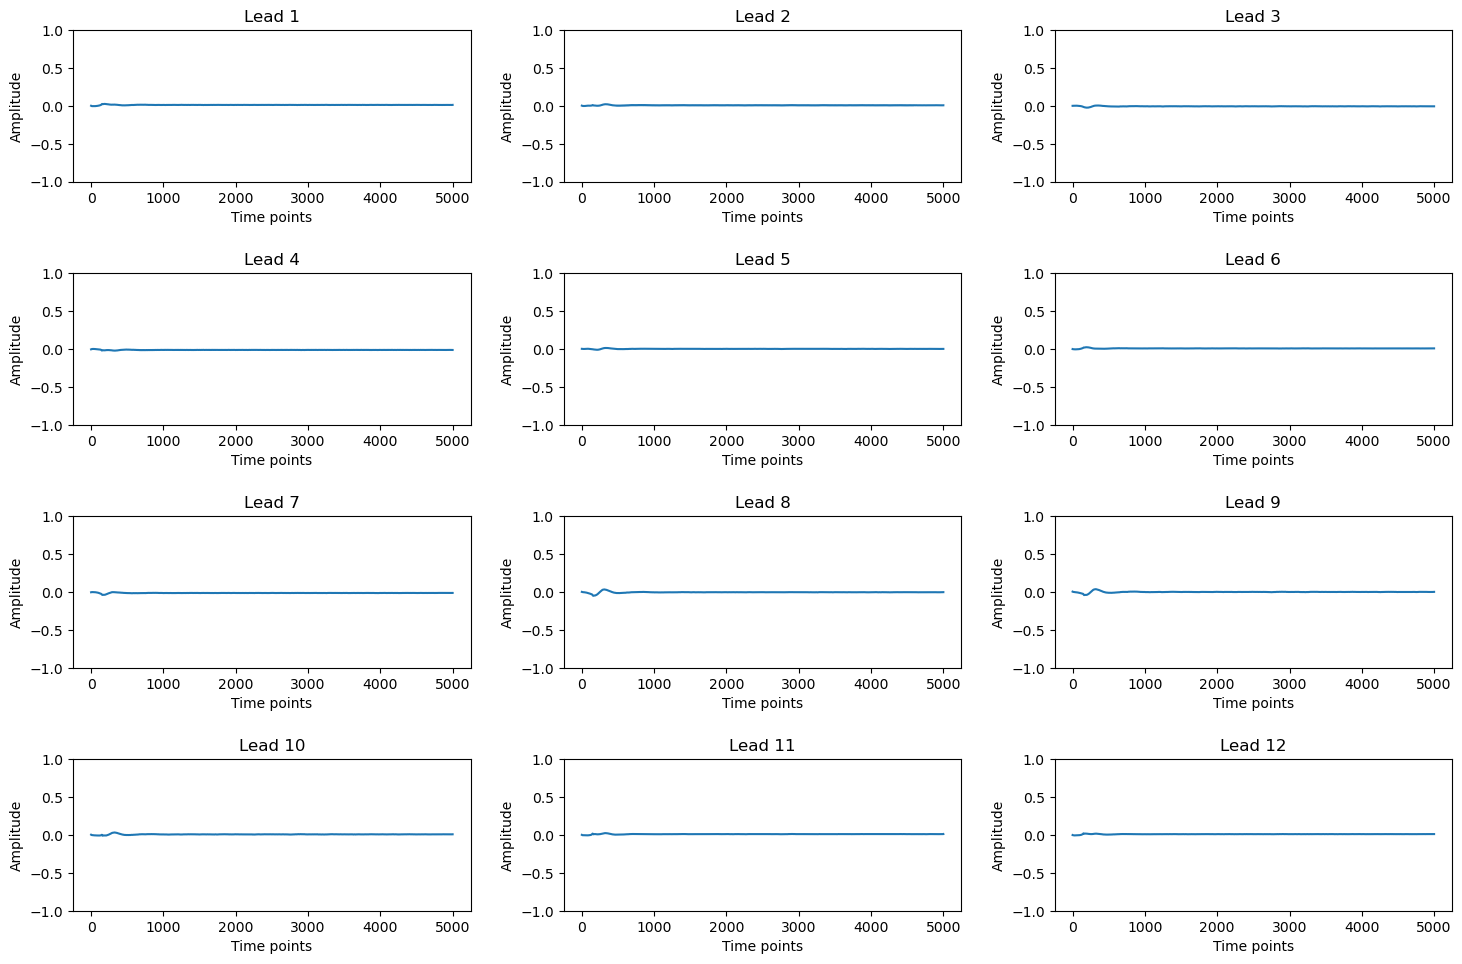

In [33]:
signal = mean_ecg.squeeze().numpy()
# signal = get_ecg(ecg_pt).squeeze().numpy()

plt.figure(figsize=(15, 10))  # Set a figure size that can comfortably fit all subplots

# Loop through each of the 12 channels
for i in range(signal.shape[1]):  # signal.shape[1] should be 12
    ax = plt.subplot(4, 3, i + 1)  # Arrange subplots in 4 rows and 3 columns
    plt.plot(signal[:, i])  # Plot the i-th channel
    plt.title(f'Lead {i+1}')
    plt.xlabel('Time points')
    plt.ylabel('Amplitude')
    ax.set_ylim([-1, 1])  # Ensure consistent y-axis limits

# Add some space between plots
plt.tight_layout(pad=2.0)
plt.show()

In [22]:
cxr = cxr.float() / 255

In [24]:
torch.all(cxr == cxr_single)

tensor(True)

: 

In [14]:
to_pil = t.ToPILImage()
pil_image = to_pil(cxr_loaded)

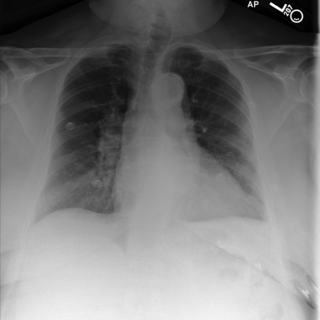

In [15]:
pil_image

In [2]:
cxr_mean = "/gpfs/scratch/as16583/symile/symile/risk_prediction/datasets/val/cxr_mean.pt"
cxr_mean = torch.load(cxr_mean)

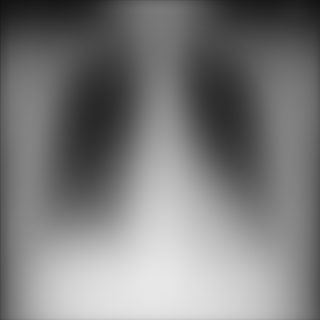

In [4]:
to_pil = t.ToPILImage()
pil_image = to_pil(cxr_mean)
pil_image

In [11]:
# cxr_single = cxr_loaded.float() / 255
cxr_single

tensor([[[0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3725, 0.5647],
         ...,
         [0.7255, 0.8039, 0.8039,  ..., 0.7765, 0.8510, 0.9020],
         [0.7333, 0.8157, 0.8118,  ..., 0.7882, 0.8510, 0.9059],
         [0.7412, 0.8196, 0.8118,  ..., 0.8000, 0.8588, 0.9098]],

        [[0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3725, 0.5647],
         ...,
         [0.7255, 0.8039, 0.8039,  ..., 0.7765, 0.8510, 0.9020],
         [0.7333, 0.8157, 0.8118,  ..., 0.7882, 0.8510, 0.9059],
         [0.7412, 0.8196, 0.8118,  ..., 0.8000, 0.8588, 0.9098]],

        [[0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3725, 0.

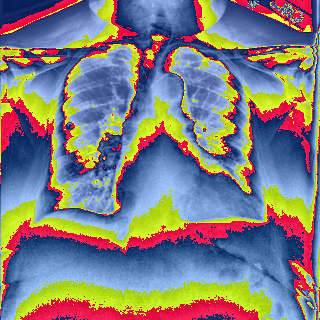

In [12]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
normalize = t.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
cxr_norm = normalize(cxr_single)
pil_image = to_pil(cxr_norm)
pil_image

In [26]:
cxr_pt = "/gpfs/data/ranganathlab/mimic-cxr-jpg/mimic-cxr-jpg-2.0.0.physionet.org/" + val_df.iloc[0].cxr_path
img = Image.open(cxr_pt).convert('RGB')

transform = t.Compose([
    t.Resize(320),
    t.CenterCrop((320, 320)),
    t.ToTensor()
])

cxr = transform(img)
# cxr = (cxr * 255)
# assert torch.all(cxr == cxr.long()), "cxr tensor is not integer-valued."
# return cxr.to(torch.uint8)

In [27]:
cxr

tensor([[[0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3725, 0.5647],
         ...,
         [0.7255, 0.8039, 0.8039,  ..., 0.7765, 0.8510, 0.9020],
         [0.7333, 0.8157, 0.8118,  ..., 0.7882, 0.8510, 0.9059],
         [0.7412, 0.8196, 0.8118,  ..., 0.8000, 0.8588, 0.9098]],

        [[0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3725, 0.5647],
         ...,
         [0.7255, 0.8039, 0.8039,  ..., 0.7765, 0.8510, 0.9020],
         [0.7333, 0.8157, 0.8118,  ..., 0.7882, 0.8510, 0.9059],
         [0.7412, 0.8196, 0.8118,  ..., 0.8000, 0.8588, 0.9098]],

        [[0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3765, 0.5686],
         [0.0431, 0.0431, 0.0392,  ..., 0.1686, 0.3725, 0.